# COMP9414 Assignment 1: Search and Planning
***Name:*** Troy Coleman
***zID:*** z5742721

In [454]:
######################## IGNORE #########################
# Global notebook rendering fixes:
# - left-align tables
# - stop Matplotlib outputs from collapsing into scroll boxes
# - prevent clipped PNG/SVG outputs
# - make long text outputs easier to read

from IPython.display import display, HTML

display(HTML("""
<style>
/* -----------------------------
   Left-align markdown / HTML tables
   ----------------------------- */
.jp-RenderedMarkdown table,
.rendered_html table,
.jp-RenderedHTMLCommon table,
.jp-MarkdownOutput table {
    margin-left: 0 !important;
    margin-right: auto !important;
}

/* -----------------------------
   Classic Jupyter Notebook:
   disable scrollable output boxes
   ----------------------------- */
div.output_scroll,
.output_scroll {
    height: auto !important;
    max-height: none !important;
    overflow-y: visible !important;
    overflow-x: visible !important;
    box-shadow: none !important;
    border-radius: 0 !important;
}

/* Classic Notebook output containers */
div.output_area,
div.output_subarea,
div.output_png,
div.output_svg,
div.output_html,
div.output_text {
    height: auto !important;
    max-height: none !important;
    overflow: visible !important;
}

/* -----------------------------
   JupyterLab / Notebook 7:
   disable output clipping/scrolling
   ----------------------------- */
.jp-OutputArea,
.jp-OutputArea-child,
.jp-OutputArea-output,
.jp-RenderedImage,
.jp-RenderedHTMLCommon,
.jp-RenderedText {
    height: auto !important;
    max-height: none !important;
    overflow: visible !important;
}

/* -----------------------------
   Matplotlib image outputs
   ----------------------------- */
.output_png img,
.jp-RenderedImage img,
.jp-OutputArea-output img {
    max-height: none !important;
    height: auto !important;
    max-width: 100% !important;
    object-fit: contain !important;
}

/* SVG plots */
.output_svg svg,
.jp-RenderedImage svg,
.jp-OutputArea-output svg {
    max-height: none !important;
    height: auto !important;
    max-width: 100% !important;
}

/* -----------------------------
   Text output readability
   ----------------------------- */
pre,
.jp-RenderedText pre,
.output_text pre {
    white-space: pre-wrap !important;
    overflow-x: visible !important;
}

/* Avoid weird nested scrollbars in output wrappers */
.jp-OutputArea-child > .jp-OutputArea-output,
.jp-OutputArea-output > div,
.output_area > .output_subarea {
    overflow: visible !important;
    max-height: none !important;
}
</style>
"""))
####################### IGNORE #########################

## Part A: Problem Formulation and Search Traces
### A.1 Office graph formulation

![office graph](images/office_graph.png)

#### A1.1
 - **Initial state:** 
     - corridor
 - **Goal test:** 
     - state == lab
 - **Actions:** 
    - Actions(corridor) = {move to mail_room, move to office_a, move to office_b}
    - Actions(lab) = {move to office_a, move to office_b, move to storage}
    - Actions(mail_room) = {move to corridor, move to storage}
    - Actions(office_a) = {move to corridor, move to lab, move to office_b}
    - Actions(office_b) = {move to corridor, move to lab, move to office_a}
    - Actions(storage) = {move to mail_room, move to lab}

    
 - **Transition model:** 
  - **Result(s, move to n) = n**.

 
 - **Path cost: sum of the edge costs** 
    - corridor → office_b → lab = 3 + 3 = 6
    - corridor → office_a → office_b → lab = 2 + 2 + 3 = 7
    - corridor → office_a → lab = 2 + 8 = 10
    - corridor → mail_room → storage → lab = 2 + 2 + 7 = 11
    - corridor → office_b → office_a → lab = 3 + 2 + 8 = 13

#### A.1.2 First three frontier updates
- **DFS (Depth First Search)**:

| Step | Popped (path so far) | Frontier after |
|:-----|:-------|:---------------|
| 1    | (corridor) | (corridor, mail_room) • (corridor, office_a) • (corridor, office_b) |
| 2    | (corridor, mail_room) | (corridor, mail_room, storage) •  (corridor, office_a) • (corridor, office_b) |
| 3    | (corridor, mail_room, storage) | (corridor, mail_room, storage, lab) •  (corridor, office_a) • (corridor, office_b)|

- **BFS (Breadth First Search)**:

| Step | Popped (path so far) | Frontier after |
|:-----|:-------|:---------------|
| 1    | (corridor) | (corridor, mail_room) • (corridor, office_a) • (corridor, office_b) |
| 2    | (corridor, mail_room) | (corridor, office_a) • (corridor, office_b) • (corridor, mail_room, storage) |
| 3    | (corridor, office_a) | (corridor, office_b) • (corridor, mail_room, storage) • (corridor, office_a, lab) • (corridor, office_a, office_b) |

- **UCS (Uniform Cost Search)**:

| Step | Popped (path so far) | Frontier after (sorted by g, path)|
|:-----|:-------|:---------------|
| 1    | g = 0 : (corridor) | (2, (corridor, mail_room)) • (2, (corridor, office_a)) • (3, (corridor, office_b)) |
| 2    | g = 2 : (corridor, mail_room) | (2, (corridor, office_a) • (3, (corridor, office_b)) • (4, (corridor, mail_room, storage) |
| 3    |g = 2 : (corridor, office_a)| (3, (corridor, office_b) • (4, (corridor, mail_room, storage) • (4, corridor, office_a, office_b) • (10, (corridor, office_a, lab)) |


#### A.1.3 Expansion order, A.1.4 Returned path and cost
| Algorithm | Expansion order | Returned path | Returned cost |
|:--|:--|:--|:--|
| DFS | corridor, mail_room, storage, lab | (corridor, mail_room, storage, lab) | 11 |
| BFS | corridor, mail_room, office_a, office_b, storage, lab | (corridor, office_a, lab) | 10 |
| UCS | corridor, mail_room, office_a, office_b, storage, lab | (corridor, office_b, lab) | 6 |


#### A.1.5 Why BFS and UCS differ
BFS orders by depth (in number of edges) whereas UCS weights a cumulative cost of all the edges. Because the two routes tie on BFS's only criterion (both two edges deep, 2+8 = 10 via office_a and 3+3 = 6 via office_b). BFS queue ordering places the 10 cost path earlier in its queue. UCS instead orders by cumulative cost. Since 6 is lower, that is the path UCS returns. 

### A.2 What is the difference between a State Space and a Search Tree?
State space describes the world, encompassing all entities and their valid states. In the example above the state space is the graph structure. Search trees are constructed algorithmically by navigating the state space. Here, the search trees are constructed using BFS, DFS and UCS search algorithms. Typically, algorithms that construct search trees need to retain a history of all visited nodes in the state space to prevent infinite search tree expansion, while state spaces are finite. In my BFS trace (above) the step-3 frontier contained both (corridor, office_b) and (corridor, office_a, office_b): the single state office_b appears as two search-tree nodes because each tree node is a path, and office_b is reachable by two routes with different costs (3 and 4)."

## Part B: Graph search implementation and comparison

Running all four algorithms on office.json, graph2.json, graph3.json.

In [455]:
import json
import math
import heapq
from collections import deque


def load_problem(path):
    with open(path) as f:
        return json.load(f)


def build_adjacency(problem):
    adj = {node["id"]: {} for node in problem["nodes"]}
    for e in problem["edges"]:
        adj[e["u"]][e["v"]] = e["cost"]
        adj[e["v"]][e["u"]] = e["cost"]
    return adj


def empty_result():
    return {"status": "error", "path": [], "plan": [], "cost": None,
            "expanded_order": [], "expanded_count": 0, "generated_count": 0,
            "frontier_peak": 0, "message": None}


def path_cost(adj, p):
    return sum(adj[p[i]][p[i + 1]] for i in range(len(p) - 1))


def run_search(problem, search_fn, **kwargs):
    solved = empty_result()
    try:
        adj = build_adjacency(problem)
        solution = search_fn(adj, problem["start"], problem["goal"], **kwargs)
        if solution is None:
            solved["status"] = "not_found"
            return solved
        p = solution["path"]
        solved["status"] = "found"
        solved["path"] = list(p)
        solved["cost"] = solution["cost"] if solution["cost"] is not None else path_cost(adj, p)
        solved["expanded_order"] = solution["expanded_order"]
        solved["expanded_count"] = len(solution["expanded_order"])
        solved["generated_count"] = solution["generated_count"]
        solved["frontier_peak"] = solution["largest_frontier"]
    except Exception as e:
        solved["message"] = str(e)
    return solved


def print_result(name, result):
    print(f"--- {name} ---")
    for field in ["status", "path", "cost", "expanded_count",
                  "generated_count", "frontier_peak", "expanded_order", "message"]:
        print(f"  {field}: {result[field]}")
    print()

In [456]:
def dfs(graph, start, goal):
    frontier = [(start,)]
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0

    while frontier:
        path = frontier.pop()
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": None,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node], reverse=True):
            generated_count += 1
            if n not in explored:
                frontier.append(path + (n,))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [457]:
def bfs(graph, start, goal):
    frontier = deque([(start,)])
    largest_frontier = 1
    expanded_order = []
    explored = set()
    generated_count = 0

    while frontier:
        path = frontier.popleft()
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": None,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                frontier.append(path + (n,))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [458]:
def ucs(graph, start, goal):
    counter = 0
    frontier = [(0, (start,), 0)]
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0
    
    while frontier:
        g, path, _ = heapq.heappop(frontier)
        node = path[-1]
        if node in explored:
            continue        # stale entry: no expanded_order append here
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": g,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                counter += 1
                heapq.heappush(frontier, (g + graph[node][n], path + (n,), counter))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [459]:
def astar(graph, start, goal, coords):
    def h(n):
        return math.dist(coords[n], coords[goal])

    counter = 0
    frontier = [(h(start), (start,), 0, 0)]      # (f, path, counter, g)
    largest_frontier = 1
    explored = set()
    expanded_order = []
    generated_count = 0
    
    while frontier:
        f, path, _, g = heapq.heappop(frontier)
        node = path[-1]
        if node in explored:
            continue
        explored.add(node)
        expanded_order.append(node)
        if node == goal:
            return {"path": path, "cost": g,
                    "expanded_order": expanded_order,
                    "largest_frontier": largest_frontier,
                    "generated_count": generated_count}
        for n in sorted(graph[node]):
            generated_count += 1
            if n not in explored:
                counter += 1
                new_g = g + graph[node][n]
                heapq.heappush(frontier, (new_g + h(n), path + (n,), counter, new_g))
                largest_frontier = max(largest_frontier, len(frontier))
    return None

In [460]:
def solve_graph(problem: dict, algorithm: str) -> dict:
    if algorithm == "astar":
        coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
        return run_search(problem, astar, coords=coords)
    searchers = {"dfs": dfs, "bfs": bfs, "ucs": ucs}
    if algorithm not in searchers:
        r = empty_result()
        r["message"] = f"unknown algorithm: {algorithm}"
        return r
    return run_search(problem, searchers[algorithm])

In [461]:
problems = {"office": load_problem("data/graphs/office.json"),
            "graph2": load_problem("data/graphs/graph2.json"),
            "graph3": load_problem("data/graphs/graph3.json")}

# DEBUGGING PRINTING
#for pname, prob in problems.items():
#    for alg in ["dfs", "bfs", "ucs", "astar"]:
#        print_result(f"{pname} / {alg}", solve_graph(prob, alg))

In [462]:
## Inline Chart
rows = []
for pname, prob in problems.items():
    for alg in ["dfs", "bfs", "ucs", "astar"]:
        r = solve_graph(prob, alg)
        rows.append({"graph": pname, "algorithm": alg,
                     "cost": round(r["cost"], 3) if r["cost"] is not None else None,
                     "expanded": r["expanded_count"],
                     "generated": r["generated_count"],
                     "frontier peak": r["frontier_peak"]})
        
print(f"{'graph':<8} {'alg':<6} {'cost':>8} {'expanded':>9} {'generated':>10} {'peak':>5}")
for row in rows:
    print(f"{row['graph']:<8} {row['algorithm']:<6} {row['cost']:>8} "
          f"{row['expanded']:>9} {row['generated']:>10} {row['frontier peak']:>5}")

graph    alg        cost  expanded  generated  peak
office   dfs        11.0         4          7     3
office   bfs        10.0         6         13     4
office   ucs         6.0         6         13     4
office   astar       6.0         5         11     4
graph2   dfs       0.997         6         21    13
graph2   bfs       0.952        17         61    12
graph2   ucs       0.886        18         64    13
graph2   astar     0.886         7         27    16
graph3   dfs       1.412         8         29    15
graph3   bfs       1.015        16         60    16
graph3   ucs       0.964        16         60    12
graph3   astar     0.964         7         27    13


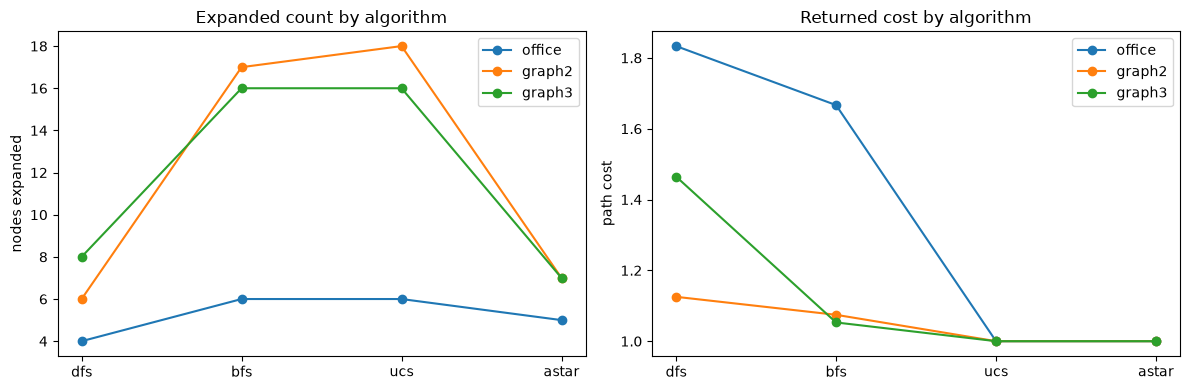

In [463]:
## MATPLOT IMPLEMENBTATION
%matplotlib inline
import matplotlib.pyplot as plt

algs = ["dfs", "bfs", "ucs", "astar"]
graphs = ["office", "graph2", "graph3"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for g in graphs:
    sub = [r for r in rows if r["graph"] == g]
    ax1.plot(algs, [r["expanded"] for r in sub], marker="o", label=g)
    opt = min(r["cost"] for r in sub)
    ax2.plot(algs, [r["cost"] / opt for r in sub], marker="o", label=g)
    
ax1.set_title("Expanded count by algorithm")
ax1.set_ylabel("nodes expanded")
ax2.set_title("Returned cost by algorithm")
ax2.set_ylabel("path cost")
ax1.legend(); ax2.legend()
plt.tight_layout()
plt.savefig("partB_comparison.png")   # saved copy for the submission zip
plt.show()

## Part C: A* heuristic behaviour analysis

The graphs chosen are **graph2.json** and **graph3.json**. 

This is because graph3 is small enough to hand inspect and reason about and graph2 is branching.

### C1.1 run UCS and A*
Plotted below are the graphs (in matplot and as a table if matplot isn't available).

In [464]:
import math
import matplotlib.pyplot as plt

def _pad_axes(ax, coords, pad=0.08):
    """Add padding so equal-aspect plots do not look cramped or cropped."""
    xs = [x for x, y in coords.values()]
    ys = [y for x, y in coords.values()]
    ax.set_xlim(min(xs) - pad, max(xs) + pad)
    ax.set_ylim(min(ys) - pad, max(ys) + pad)


def plot_graph(problem, paths=None, title="", fname=None):
    goal = problem["goal"]
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    fig, ax = plt.subplots(figsize=(7, 7))

    for e in problem["edges"]:
        (x1, y1), (x2, y2) = coords[e["u"]], coords[e["v"]]
        ax.plot([x1, x2], [y1, y2], color="0.8", lw=1, zorder=1)
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{e['cost']}",
            ha="center",
            va="center",
            fontsize=5.5,
            color="0.55",
            zorder=2,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8),
        )

    for label, (path, color, style, gs) in (paths or {}).items():
        xs = [coords[n][0] for n in path]
        ys = [coords[n][1] for n in path]

        ax.plot(xs, ys, color=color, lw=2.5, linestyle=style, zorder=2, label=label)

        if gs:
            for n, gval in zip(path, gs):
                x, y = coords[n]
                ax.text(
                    x,
                    y + 0.038,
                    f"g={gval:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=6.5,
                    color=color,
                    zorder=4,
                )

    for nid, (x, y) in coords.items():
        endpoint = nid in (problem["start"], problem["goal"])

        ax.scatter(
            x,
            y,
            s=420,
            zorder=3,
            color="#9fe1cb" if endpoint else "white",
            edgecolors="#0f6e56" if endpoint else "0.4",
            linewidths=1,
        )

        ax.text(x, y, nid, ha="center", va="center", zorder=4, fontsize=9)

        h = math.dist(coords[nid], coords[goal])
        ax.text(
            x,
            y - 0.048,
            f"h={h:.2f}",
            ha="center",
            va="top",
            fontsize=6.5,
            color="0.2",
            zorder=4,
        )

    # Fix: prevents visual collapse/cropping when aspect is equal and axis is hidden.
    _pad_axes(ax, coords, pad=0.08)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    ax.set_title(title)

    if paths:
        ax.legend(loc="lower right", fontsize=8)

    if fname:
        fig.savefig(fname, dpi=150, bbox_inches="tight", pad_inches=0.15)

    plt.show()
    plt.close(fig)


def plot_expansions(problem, expanded_order, title="", fname=None):
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    fig, ax = plt.subplots(figsize=(7, 7))

    for e in problem["edges"]:
        (x1, y1), (x2, y2) = coords[e["u"]], coords[e["v"]]
        ax.plot([x1, x2], [y1, y2], color="0.8", lw=1, zorder=1)
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{e['cost']}",
            ha="center",
            va="center",
            fontsize=5.5,
            color="0.55",
            zorder=2,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8),
        )

    rank = {n: i + 1 for i, n in enumerate(expanded_order)}

    for nid, (x, y) in coords.items():
        hit = nid in rank

        ax.scatter(
            x,
            y,
            s=420,
            zorder=3,
            color="#fac775" if hit else "white",
            edgecolors="#854f0b" if hit else "0.6",
            linewidths=1,
        )

        label = f"{nid}\n{rank[nid]}" if hit else nid
        ax.text(x, y, label, ha="center", va="center", fontsize=7, zorder=4)

    # Fix: prevents equal-aspect plots from looking collapsed/cropped.
    _pad_axes(ax, coords, pad=0.08)

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    ax.set_title(title)

    if fname:
        fig.savefig(fname, dpi=150, bbox_inches="tight", pad_inches=0.15)

    plt.show()
    plt.close(fig)

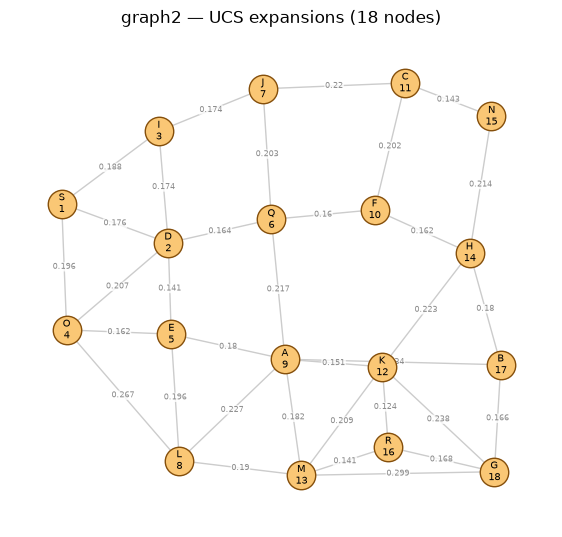

In [465]:
ucs_result = solve_graph(problems["graph2"], "ucs")
plot_expansions(
    problems["graph2"],
    ucs_result["expanded_order"],
    title="graph2 — UCS expansions (18 nodes)",
    fname="partC_graph2_ucs_expansions.png",
)

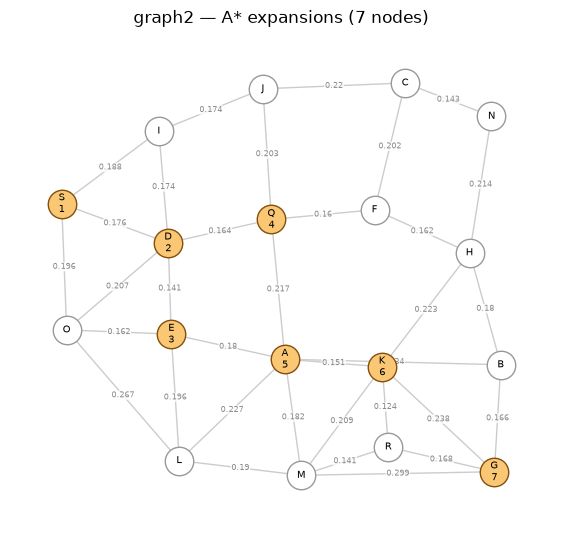

In [466]:
astar_result = solve_graph(problems["graph2"], "astar")
plot_expansions(
    problems["graph2"],
    astar_result["expanded_order"],
    title="graph2 — A* expansions (7 nodes)",
    fname="partC_graph2_astar_expansions.png",
)


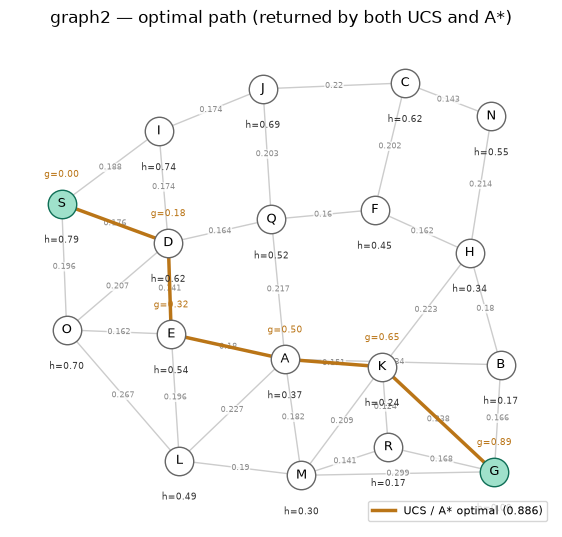

In [467]:
plot_graph(
    problems["graph2"],
    paths={
        "UCS / A* optimal (0.886)": (
            ["S", "D", "E", "A", "K", "G"],
            "#ba7517",
            "solid",
            [0, 0.176, 0.317, 0.497, 0.648, 0.886],
        )
    },
    title="graph2 — optimal path (returned by both UCS and A*)",
    fname="partC_graph2_optimal.png",
)

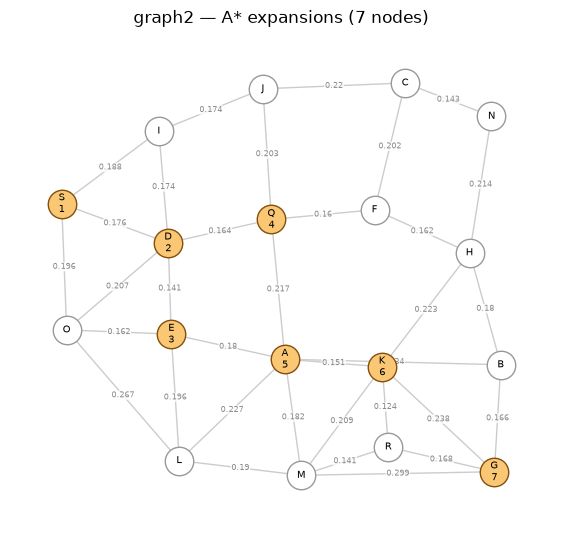

In [468]:
astar_result = solve_graph(problems["graph2"], "astar")
plot_expansions(problems["graph2"], astar_result["expanded_order"],
                title="graph2 — A* expansions (7 nodes)",
                fname="partC_graph2_astar_expansions.png")

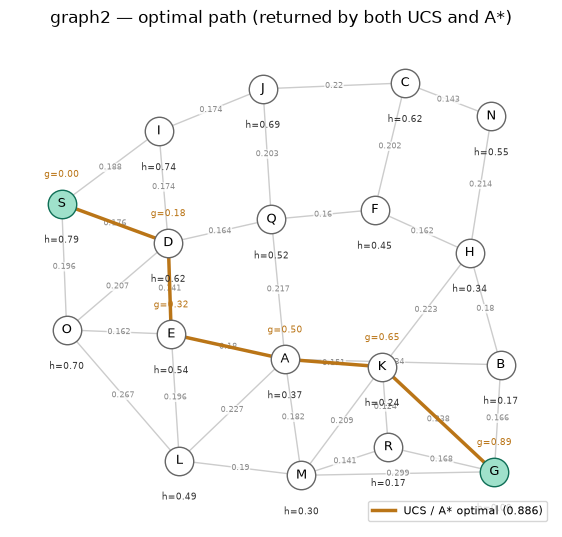

In [469]:
plot_graph(problems["graph2"],
           paths={"UCS / A* optimal (0.886)":
                  (["S", "D", "E", "A", "K", "G"], "#ba7517", "solid",
                   [0, 0.176, 0.317, 0.497, 0.648, 0.886])},
           title="graph2 — optimal path (returned by both UCS and A*)",
           fname="partC_graph2_optimal.png")

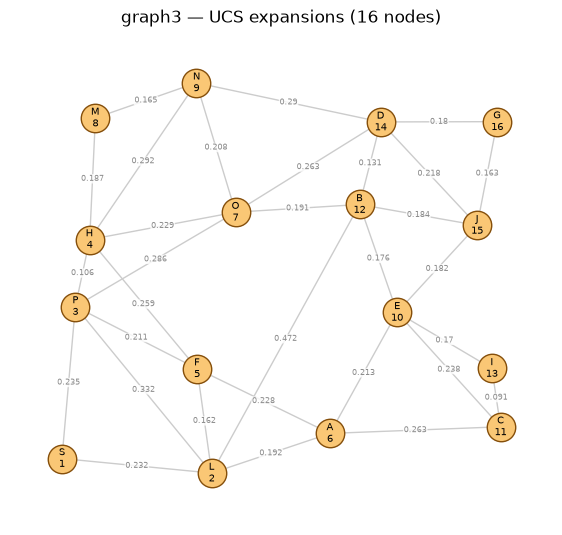

In [470]:
ucs_result   = solve_graph(problems["graph3"], "ucs")
plot_expansions(problems["graph3"], ucs_result["expanded_order"],
                title="graph3 — UCS expansions (16 nodes)",
                fname="partC_graph3_ucs_expansions.png")

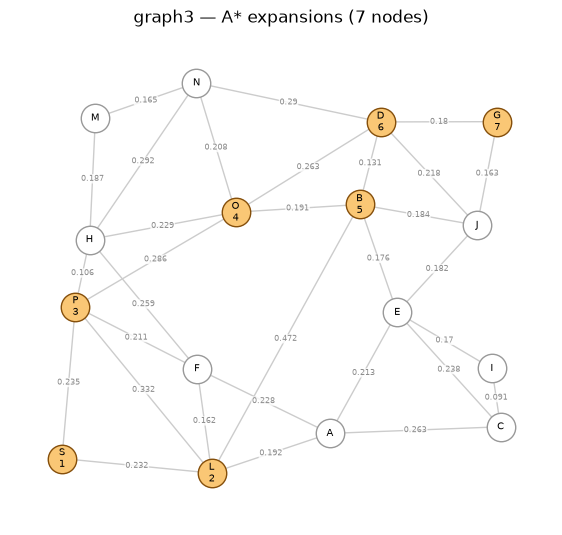

In [471]:
astar_result = solve_graph(problems["graph3"], "astar")
plot_expansions(problems["graph3"], astar_result["expanded_order"],
                title="graph3 — A* expansions (7 nodes)",
                fname="partC_graph2_astar_expansions.png")

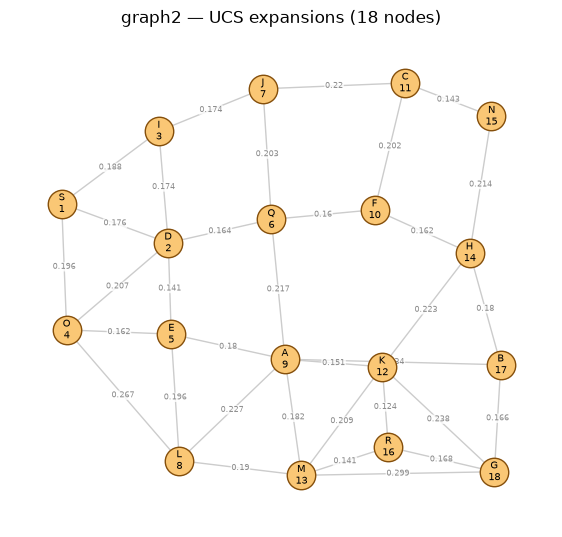

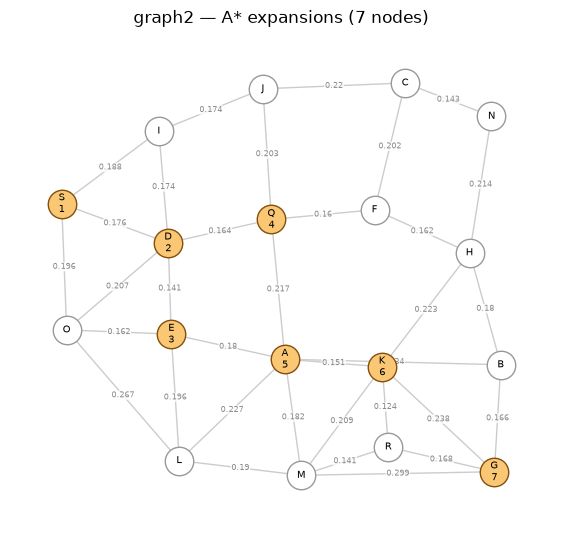

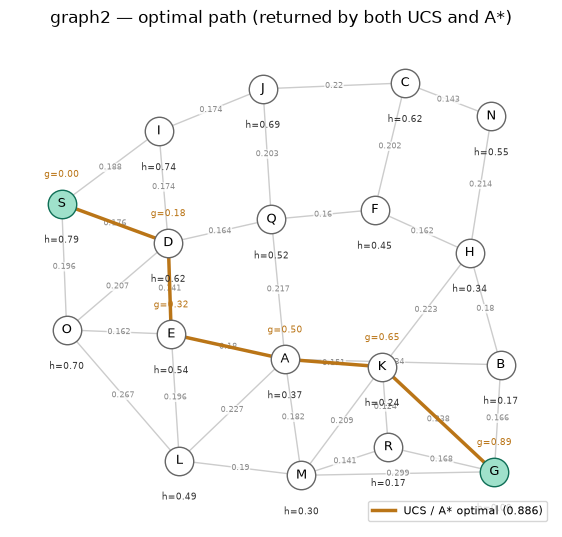

In [472]:
# -------------------------
# graph2 plots
# -------------------------

ucs_result = solve_graph(problems["graph2"], "ucs")
plot_expansions(
    problems["graph2"],
    ucs_result["expanded_order"],
    title="graph2 — UCS expansions (18 nodes)",
    fname="partC_graph2_ucs_expansions.png",
)

astar_result = solve_graph(problems["graph2"], "astar")
plot_expansions(
    problems["graph2"],
    astar_result["expanded_order"],
    title="graph2 — A* expansions (7 nodes)",
    fname="partC_graph2_astar_expansions.png",
)

plot_graph(
    problems["graph2"],
    paths={
        "UCS / A* optimal (0.886)": (
            ["S", "D", "E", "A", "K", "G"],
            "#ba7517",
            "solid",
            [0, 0.176, 0.317, 0.497, 0.648, 0.886],
        )
    },
    title="graph2 — optimal path (returned by both UCS and A*)",
    fname="partC_graph2_optimal.png",
)



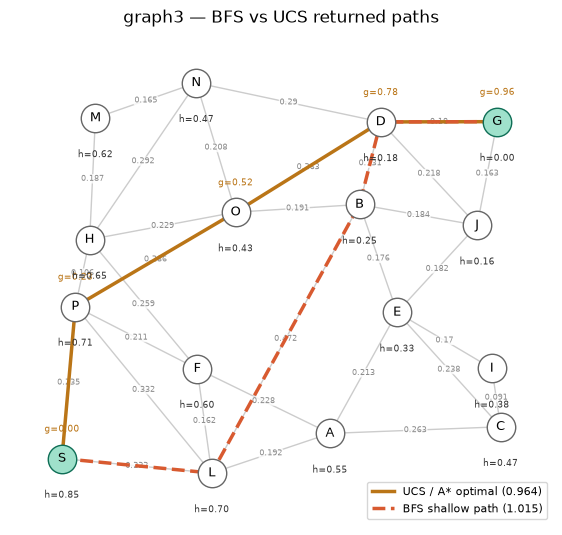

In [473]:
plot_graph(problems["graph3"],
           paths={"UCS / A* optimal (0.964)":
                  (["S", "P", "O", "D", "G"], "#ba7517", "solid",
                   [0, 0.235, 0.521, 0.784, 0.964]),
                  "BFS shallow path (1.015)":
                  (["S", "L", "B", "D", "G"], "#d85a30", "dashed", None)},
           title="graph3 — BFS vs UCS returned paths",
           fname="partB_graph3_paths.png")

In [474]:
## IF MATPLOT LIB ISN'T VISIBLE
def print_graph_text(problem, name=""):
    coords = {n["id"]: (n["x"], n["y"]) for n in problem["nodes"]}
    adj = build_adjacency(problem)
    goal = problem["goal"]

    print(f"=== {name}  (start: {problem['start']}, goal: {goal}) ===")
    print(f"{len(coords)} nodes, {len(problem['edges'])} edges\n")
    print(f"{'node':<10} {'(x, y)':<18} {'h to goal':>9}   neighbours (cost)")
    for nid in sorted(coords):
        x, y = coords[nid]
        h = math.dist(coords[nid], coords[goal])
        nbrs = ", ".join(f"{n} ({adj[nid][n]})" for n in sorted(adj[nid]))
        mark = " *" if nid in (problem["start"], goal) else "  "
        print(f"{nid:<8}{mark} ({x:.3f}, {y:.3f})   {h:>9.3f}   {nbrs}")
    print()

for pname, prob in problems.items():
    print_graph_text(prob, pname)

=== office  (start: corridor, goal: lab) ===
6 nodes, 8 edges

node       (x, y)             h to goal   neighbours (cost)
corridor * (0.000, 0.000)       2.000   mail_room (2.0), office_a (2.0), office_b (3.0)
lab      * (2.000, 0.000)       0.000   office_a (8.0), office_b (3.0), storage (7.0)
mail_room   (-1.000, 0.000)       3.000   corridor (2.0), storage (2.0)
office_a   (0.000, 1.000)       2.236   corridor (2.0), lab (8.0), office_b (2.0)
office_b   (1.000, 0.000)       1.000   corridor (3.0), lab (3.0), office_a (2.0)
storage    (-2.000, 0.000)       4.000   lab (7.0), mail_room (2.0)

=== graph2  (start: S, goal: G) ===
18 nodes, 34 edges

node       (x, y)             h to goal   neighbours (cost)
A          (0.502, 0.381)       0.368   B (0.334), E (0.18), K (0.151), L (0.227), M (0.182), Q (0.217)
B          (0.836, 0.372)       0.166   A (0.334), G (0.166), H (0.18)
C          (0.688, 0.808)       0.617   F (0.202), J (0.22), N (0.143)
D          (0.322, 0.561)       0.61

## C.2 Empirical comparison

### C.2.2 UCS versus A*

| Graph | Algorithm | Returned cost | Expanded | Generated | Frontier peak |
|---|---:|---:|---:|---:|---:|
| graph2 | UCS | 0.886 | 18 | 64 | 13 |
| graph2 | A* | 0.886 | 7 | 27 | 16 |
| graph3 | UCS | 0.964 | 16 | 60 | 12 |
| graph3 | A* | 0.964 | 7 | 27 | 13 |

For both `graph2` and `graph3`, UCS and A* returned the same final path cost. This means that, on these two supplied graphs, the straight-line heuristic did not change the quality of the returned solution.

However, A* expanded far fewer nodes. On `graph2`, A* expanded 7 nodes compared with 18 for UCS. On `graph3`, A* also expanded 7 nodes compared with 16 for UCS. This shows that the heuristic changed the search effort: A* reached the goal with fewer expansions because it used both the path cost so far, \(g(n)\), and the estimated distance to the goal, \(h(n)\).

The frontier peak is slightly higher for A* in both cases. This means A* may keep more candidates waiting on the frontier at once, but it still expands fewer total nodes before reaching the goal.

---

### C.2.3 Point where UCS and A* choose different frontier entries

On `graph2`, UCS and A* agree for the first two expansions:

```text
UCS: S, D, ...
A*:  S, D, ...
```

The first difference occurs at the third expansion:

```text
UCS: S, D, I, ...
A*:  S, D, E, ...
```

UCS expands `I` because UCS only considers the path cost so far. The cost to reach `I` is lower:

\[
g(I)=0.188
\]

while the cost to reach `E` is:

\[
g(E)=0.317
\]

So UCS chooses `I`.

A* chooses `E` instead because it uses:

\[
f(n)=g(n)+h(n)
\]

For `E`:

\[
f(E)=0.317+0.544=0.861
\]

For `I`:

\[
f(I)=0.188+0.740=0.928
\]

Although `I` has the smaller path cost so far, `E` has the smaller estimated total cost. Therefore A* expands `E`.

On `graph3`, UCS and A* agree for the first three expansions:

```text
UCS: S, L, P, ...
A*:  S, L, P, ...
```

The first difference occurs at the fourth expansion:

```text
UCS: S, L, P, H, ...
A*:  S, L, P, O, ...
```

UCS expands `H` because it has the lowest path cost so far:

\[
g(H)=0.341
\]

A* expands `O` because its estimated total cost is lower:

\[
f(O)=g(O)+h(O)=0.521+0.427=0.948
\]

whereas:

\[
f(H)=g(H)+h(H)=0.341+0.654=0.995
\]

So A* prefers `O` even though it is more expensive to reach so far, because it appears closer to the goal.

---

### C.2.4 How the heuristic changed the search effort

The heuristic made A* more goal-directed than UCS.

UCS expands nodes in order of cheapest known path cost, \(g(n)\). This means UCS may spend time exploring cheap partial paths that are not moving strongly toward the goal.

A* expands nodes according to:

\[
f(n)=g(n)+h(n)
\]

This means A* balances the cost already paid with an estimate of the remaining distance. In these graphs, that caused A* to skip many nodes that UCS expanded.

| Graph | UCS expanded | A* expanded | Expanded by UCS but not by A* |
|---|---:|---:|---|
| graph2 | 18 | 7 | I, O, J, L, F, C, M, H, N, R, B |
| graph3 | 16 | 7 | H, F, A, M, N, E, C, I, J |

For `graph2`, A* focuses on the sequence:

```text
S, D, E, Q, A, K, G
```

For `graph3`, A* focuses on:

```text
S, L, P, O, B, D, G
```

These expansion orders show that A* tends to move toward nodes with smaller straight-line distance to the goal, while still accounting for the cost already paid. The result is fewer expanded nodes and fewer generated candidates in both graphs.

---

### C.2.5 Limitation of coordinate distance

A limitation of the straight-line heuristic is that graph edge costs do not always represent physical distance. The nodes have coordinates, but the edge weights may represent something else, such as travel time, difficulty, congestion, risk, or another arbitrary cost.

Because of this, a node that is geometrically close to the goal may not actually have a cheap path to the goal. For example, a route may look short in straight-line distance but require expensive edges, while another route may look longer geometrically but have cheaper edge costs.

In these two runs, A* returned the same path cost as UCS, so the heuristic worked well empirically. However, this is not guaranteed for every weighted graph unless the heuristic is admissible, meaning it never overestimates the true remaining cost. If edge costs and coordinates diverge too much, straight-line distance may become a poor guide.

# Part D — STRIPS modelling and forward BFS planning

Implemented action schemas:

- `move(robot, from, to)`;
- `pickup_keycard(robot, keycard, room)`;
- `pickup_parcel(robot, parcel, room)`;
- `unlock_door(robot, keycard, lab_door, here, there)`;
- `drop_parcel(robot, parcel, room)`.

The state is represented as a set of fact tuples. The BFS frontier stores `(facts, plan)` pairs, where `plan` is the grounded action sequence used to reach that state.


## Part D.2 Plan diagnosis for `lab_via_office_b`

Proposed plan:

1. `move(robot, corridor, mail_room)`
2. `pickup_parcel(robot, parcel, mail_room)`
3. `move(robot, mail_room, corridor)`
4. `move(robot, corridor, office_b)`
5. `move(robot, office_b, lab)`
6. `drop_parcel(robot, parcel, lab)`

In `lab_via_office_b`, the locked door connects `office_b` and `lab`, and the door starts locked. The first action that is not applicable when reached is:

```text
move(robot, office_b, lab)
```

The blocking false fact is:

```text
unlocked(lab_door)
```

At that point, `at(robot,office_b)` is true and `connected(office_b,lab)` is true, but crossing the locked lab-door edge requires `unlocked(lab_door)`, which is false.

Simply inserting `unlock_door(robot, keycard, lab_door, office_b, lab)` immediately before the blocked action is still not enough, because the robot has not picked up the keycard. The missing precondition for the inserted unlock action would be:

```text
has(robot,keycard)
```

A valid repaired plan is:

1. `move(robot, corridor, mail_room)`
2. `pickup_parcel(robot, parcel, mail_room)`
3. `move(robot, mail_room, corridor)`
4. `move(robot, corridor, office_a)`
5. `pickup_keycard(robot, keycard, office_a)`
6. `move(robot, office_a, corridor)`
7. `move(robot, corridor, office_b)`
8. `unlock_door(robot, keycard, lab_door, office_b, lab)`
9. `move(robot, office_b, lab)`
10. `drop_parcel(robot, parcel, lab)`

Step 8 first makes `unlocked(lab_door)` true. Step 10 applies `drop_parcel`, which deletes `carrying(robot,parcel)` and adds `at(parcel,lab)`. Therefore the final state satisfies the goal `{at(parcel,lab)}`.

In [485]:
PLANNING_FILES = {
    "canonical_delivery": "data/planning/canonical_delivery.json",
    "unlocked_lab": "data/planning/unlocked_lab.json",
    "lab_via_office_b": "data/planning/lab_via_office_b.json",
}

planning_problems = {
    name: load_problem(path)
    for name, path in PLANNING_FILES.items()
}

def fact_to_str(fact):
    """Readable fact representation such as at(robot,corridor)."""
    fact = tuple(fact)
    return f"{fact[0]}(" + ",".join(fact[1:]) + ")"


def canonical_state_tuple(facts):
    """Canonical tuple used for visited-state checks."""
    return tuple(sorted(fact_to_str(fact) for fact in facts))


def canonical_state_string(facts):
    """Readable canonical state id for expanded_order."""
    return "{" + "; ".join(canonical_state_tuple(facts)) + "}"


def edge_key(a, b):
    return tuple(sorted((a, b)))


def office_planning_edges(problem):
    """
    Movement topology for the supplied office-delivery planning cases.

    The corridor is connected to each non-lab office room. The lab is connected
    by the edge named in problem['locked_edge'].
    """
    rooms = set(problem.get("rooms", []))
    edges = []

    for room in sorted(rooms):
        if room not in {"corridor", "lab"}:
            edges.append(("corridor", room))

    locked = tuple(problem.get("locked_edge", []))
    if len(locked) == 2:
        edges.append(locked)
    elif "lab" in rooms and "corridor" in rooms:
        edges.append(("corridor", "lab"))

    seen = set()
    unique = []
    for a, b in edges:
        if a in rooms and b in rooms:
            key = edge_key(a, b)
            if key not in seen:
                seen.add(key)
                unique.append((a, b))
    return unique


def initial_planning_facts(problem):
    facts = {
        ("at", "robot", problem["robot_start"]),
        ("at", "parcel", problem["parcel_start"]),
        ("at", "keycard", problem["keycard_start"]),
    }

    for a, b in office_planning_edges(problem):
        facts.add(("connected", a, b))
        facts.add(("connected", b, a))

    locked = tuple(problem.get("locked_edge", []))
    if len(locked) == 2:
        a, b = locked
        facts.add(("door_between", "lab_door", a, b))
        facts.add(("door_between", "lab_door", b, a))

    if problem.get("door_locked", False):
        facts.add(("locked", "lab_door"))
    else:
        facts.add(("unlocked", "lab_door"))

    return frozenset(facts)


def planning_goal_satisfied(facts, goal):
    return all(tuple(goal_fact) in facts for goal_fact in goal)


def format_action(name, *args):
    return f"{name}(" + ", ".join(args) + ")"


def parse_action_signature(action):
    name, rest = action.split("(", 1)
    args = tuple(x.strip() for x in rest[:-1].split(","))
    return name, args


def applicable_planning_actions(problem, facts):
    """Return applicable grounded actions in deterministic order."""
    rooms = sorted(problem.get("rooms", []))
    actions = []

    locked = tuple(problem.get("locked_edge", []))
    locked_edges = {edge_key(*locked)} if len(locked) == 2 else set()

    # move(robot, from, to)
    for fr in rooms:
        if ("at", "robot", fr) not in facts:
            continue
        for to in rooms:
            if fr == to:
                continue
            if ("connected", fr, to) not in facts:
                continue
            crosses_lab_door = edge_key(fr, to) in locked_edges
            if crosses_lab_door and ("unlocked", "lab_door") not in facts:
                continue
            actions.append(format_action("move", "robot", fr, to))

    # pickup_keycard(robot, keycard, room)
    for room in rooms:
        if ("at", "robot", room) in facts and ("at", "keycard", room) in facts:
            actions.append(format_action("pickup_keycard", "robot", "keycard", room))

    # pickup_parcel(robot, parcel, room)
    for room in rooms:
        if ("at", "robot", room) in facts and ("at", "parcel", room) in facts:
            actions.append(format_action("pickup_parcel", "robot", "parcel", room))

    # unlock_door(robot, keycard, lab_door, here, there)
    if ("has", "robot", "keycard") in facts and ("locked", "lab_door") in facts and len(locked) == 2:
        a, b = locked
        for here, there in [(a, b), (b, a)]:
            if ("at", "robot", here) in facts and ("door_between", "lab_door", here, there) in facts:
                actions.append(format_action("unlock_door", "robot", "keycard", "lab_door", here, there))

    # drop_parcel(robot, parcel, room)
    for room in rooms:
        if ("at", "robot", room) in facts and ("carrying", "robot", "parcel") in facts:
            actions.append(format_action("drop_parcel", "robot", "parcel", room))

    return sorted(actions)


def apply_planning_action(problem, facts, action):
    """Apply STRIPS delete and add effects for one grounded action."""
    name, args = parse_action_signature(action)
    next_facts = set(facts)

    if name == "move":
        _, fr, to = args
        next_facts.remove(("at", "robot", fr))
        next_facts.add(("at", "robot", to))

    elif name == "pickup_keycard":
        _, keycard, room = args
        next_facts.remove(("at", keycard, room))
        next_facts.add(("has", "robot", keycard))

    elif name == "pickup_parcel":
        _, parcel, room = args
        next_facts.remove(("at", parcel, room))
        next_facts.add(("carrying", "robot", parcel))

    elif name == "unlock_door":
        next_facts.discard(("locked", "lab_door"))
        next_facts.add(("unlocked", "lab_door"))

    elif name == "drop_parcel":
        _, parcel, room = args
        next_facts.remove(("carrying", "robot", parcel))
        next_facts.add(("at", parcel, room))

    else:
        raise ValueError(f"Unknown action: {action}")

    return frozenset(next_facts)


def planning_result(status, plan, expanded_states, generated_count, frontier_peak, message=None):
    result = {
        "status": status,
        "path": [],
        "plan": plan,
        "cost": len(plan) if status == "found" else None,
        "expanded_order": [canonical_state_string(s) for s in expanded_states],
        "expanded_from IPython.display import display, Markdown"

def show_markdown(text):
    """Render a string as Markdown in the notebook."""
    display(Markdown(text))


def markdown_table(headers, rows):
    """Create a simple Markdown table from headers and rows."""
    def clean(value):
        if value is None:
            return ""
        value = str(value)
        value = value.replace("\n", "<br>")
        value = value.replace("|", "\\|")
        return value

    header_line = "| " + " | ".join(clean(h) for h in headers) + " |"
    separator_line = "| " + " | ".join("---" for _ in headers) + " |"

    row_lines = []
    for row in rows:
        row_lines.append("| " + " | ".join(clean(v) for v in row) + " |")

    return "\n".join([header_line, separator_line] + row_lines)count": len(expanded_states),
        "generated_count": generated_count,
        "frontier_peak": frontier_peak,
    }
    if message is not None:
        result["message"] = message
    return result


def solve_planning(problem: dict) -> dict:
    """Forward BFS STRIPS planner with assignment-required return fields."""
    try:
        start = initial_planning_facts(problem)
        frontier = deque([(start, [])])
        visited = {canonical_state_tuple(start)}
        expanded_states = []
        generated_count = 0
        frontier_peak = 1

        while frontier:
            facts, plan = frontier.popleft()
            expanded_states.append(facts)

            if planning_goal_satisfied(facts, problem.get("goal", [])):
                return planning_result("found", plan, expanded_states, generated_count, frontier_peak)

            for action in applicable_planning_actions(problem, facts):
                generated_count += 1
                next_facts = apply_planning_action(problem, facts, action)
                next_id = canonical_state_tuple(next_facts)
                if next_id in visited:
                    continue
                visited.add(next_id)
                frontier.append((next_facts, plan + [action]))
                frontier_peak = max(frontier_peak, len(frontier))

        return planning_result("not_found", [], expanded_states, generated_count, frontier_peak)

    except Exception as exc:
        return planning_result("error", [], [], 0, 0, str(exc))


SyntaxError: unterminated string literal (detected at line 215) (1368230026.py, line 215)

In [484]:
from IPython.display import display, Markdown

def show_markdown(text):
    """Render a string as Markdown in the notebook."""
    display(Markdown(text))


def markdown_table(headers, rows):
    """Create a simple Markdown table from headers and rows."""
    def clean(value):
        if value is None:
            return ""
        value = str(value)
        value = value.replace("\n", "<br>")
        value = value.replace("|", "\\|")
        return value

    header_line = "| " + " | ".join(clean(h) for h in headers) + " |"
    separator_line = "| " + " | ".join("---" for _ in headers) + " |"

    row_lines = []
    for row in rows:
        row_lines.append("| " + " | ".join(clean(v) for v in row) + " |")

    return "\n".join([header_line, separator_line] + row_lines)

from IPython.display import display, Markdown

def show_markdown(text):
    """Render a string as Markdown in the notebook."""
    display(Markdown(text))


def markdown_table(headers, rows):
    """Create a simple Markdown table from headers and rows."""
    def clean(value):
        if value is None:
            return ""
        value = str(value)
        value = value.replace("\n", "<br>")
        value = value.replace("|", "\\|")
        return value

    header_line = "| " + " | ".join(clean(h) for h in headers) + " |"
    separator_line = "| " + " | ".join("---" for _ in headers) + " |"

    row_lines = []
    for row in rows:
        row_lines.append("| " + " | ".join(clean(v) for v in row) + " |")

    return "\n".join([header_line, separator_line] + row_lines)


def fmt_cost(cost):
    """Format search/planning costs for readable tables."""
    if cost is None:
        return ""
    if isinstance(cost, int):
        return str(cost)
    if isinstance(cost, float):
        return f"{cost:.3f}"
    return str(cost)

In [481]:
def run_planning_suite(cases):
    results = {}
    rows = []
    for case_name, problem in cases.items():
        result = solve_planning(problem)
        results[case_name] = result
        rows.append([
            case_name,
            result["status"],
            result["cost"],
            result["expanded_count"],
            result["generated_count"],
            result["frontier_peak"],
            "<br>".join(f"{i+1}. {a}" for i, a in enumerate(result["plan"])),
        ])
    return results, rows

planning_results, planning_rows = run_planning_suite({
    "canonical_delivery": planning_problems["canonical_delivery"],
    "unlocked_lab": planning_problems["unlocked_lab"],
    "lab_via_office_b": planning_problems["lab_via_office_b"],
})

show_markdown(markdown_table(
    ["Case", "Status", "Plan length", "Expanded", "Generated", "Frontier peak", "Final plan"],
    planning_rows,
))

| Case | Status | Plan length | Expanded | Generated | Frontier peak | Final plan |
| --- | --- | --- | --- | --- | --- | --- |
| canonical_delivery | found | 9 | 60 | 125 | 13 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, office_a)<br>5. pickup_keycard(robot, keycard, office_a)<br>6. move(robot, office_a, corridor)<br>7. unlock_door(robot, keycard, lab_door, corridor, lab)<br>8. move(robot, corridor, lab)<br>9. drop_parcel(robot, parcel, lab) |
| unlocked_lab | found | 5 | 21 | 43 | 11 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, lab)<br>5. drop_parcel(robot, parcel, lab) |
| lab_via_office_b | found | 10 | 60 | 128 | 10 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, office_a)<br>5. pickup_keycard(robot, keycard, office_a)<br>6. move(robot, office_a, corridor)<br>7. move(robot, corridor, office_b)<br>8. unlock_door(robot, keycard, lab_door, office_b, lab)<br>9. move(robot, office_b, lab)<br>10. drop_parcel(robot, parcel, lab) |

## Part D.4 Planning comparison

The `unlocked_lab` case can be solved with fewer actions because the planner does not need to visit `office_a` to collect the keycard and does not need an `unlock_door` action. It only needs to collect the parcel, move to the lab, and drop it.

The `canonical_delivery` case has the lab door locked between `corridor` and `lab`, so a valid plan must make `has(robot,keycard)` true before it can make `unlocked(lab_door)` true. This adds the detour to `office_a`, the pickup action, and the unlock action.

## Reusable evaluation cell

Loads all supplied examples, runs every required algorithm, prints
a readable table, and writes the summary to zID_results.json.

In [482]:
# Reusable evaluation cell
# Loads all supplied examples, runs every required algorithm,
# prints readable tables, and writes the summary to z5742721_results.json.

import json
from IPython.display import display, Markdown


def show_markdown(text):
    """Render a string as Markdown in the notebook."""
    display(Markdown(text))


def markdown_table(headers, rows):
    """Create a simple Markdown table from headers and rows."""
    def clean(value):
        if value is None:
            return ""
        value = str(value)
        value = value.replace("\n", "<br>")
        value = value.replace("|", "\\|")
        return value

    header_line = "| " + " | ".join(clean(h) for h in headers) + " |"
    separator_line = "| " + " | ".join("---" for _ in headers) + " |"

    row_lines = []
    for row in rows:
        row_lines.append("| " + " | ".join(clean(v) for v in row) + " |")

    return "\n".join([header_line, separator_line] + row_lines)


def fmt_cost(cost):
    """Format search/planning costs for readable tables."""
    if cost is None:
        return ""
    if isinstance(cost, int):
        return str(cost)
    if isinstance(cost, float):
        return f"{cost:.3f}"
    return str(cost)


EVAL_GRAPH_CASES = {
    "office": load_problem("data/graphs/office.json"),
    "graph1": load_problem("data/graphs/graph1.json"),
    "graph2": load_problem("data/graphs/graph2.json"),
    "graph3": load_problem("data/graphs/graph3.json"),
}

EVAL_PLANNING_CASES = {
    "canonical_delivery": load_problem("data/planning/canonical_delivery.json"),
    "unlocked_lab": load_problem("data/planning/unlocked_lab.json"),
    "lab_via_office_b": load_problem("data/planning/lab_via_office_b.json"),
}

EVAL_ALGORITHMS = ["dfs", "bfs", "ucs", "astar"]

final_results = {
    "graph_search": {},
    "planning": {},
}

graph_eval_rows = []

for case_name, problem in EVAL_GRAPH_CASES.items():
    final_results["graph_search"][case_name] = {}

    for alg in EVAL_ALGORITHMS:
        result = solve_graph(problem, alg)
        final_results["graph_search"][case_name][alg] = result

        graph_eval_rows.append([
            case_name,
            alg,
            result["status"],
            " → ".join(result["path"]),
            fmt_cost(result["cost"]),
            result["expanded_count"],
            result["generated_count"],
            result["frontier_peak"],
            " → ".join(result["expanded_order"]),
        ])


planning_eval_rows = []

for case_name, problem in EVAL_PLANNING_CASES.items():
    result = solve_planning(problem)
    final_results["planning"][case_name] = result

    planning_eval_rows.append([
        case_name,
        result["status"],
        result["cost"],
        result["expanded_count"],
        result["generated_count"],
        result["frontier_peak"],
        "<br>".join(f"{i + 1}. {a}" for i, a in enumerate(result["plan"])),
    ])


show_markdown("## Final graph-search evaluation\n\n" + markdown_table(
    [
        "Case",
        "Algorithm",
        "Status",
        "Path",
        "Cost",
        "Expanded",
        "Generated",
        "Frontier peak",
        "Expansion order",
    ],
    graph_eval_rows,
))

show_markdown("## Final planning evaluation\n\n" + markdown_table(
    [
        "Case",
        "Status",
        "Plan length",
        "Expanded",
        "Generated",
        "Frontier peak",
        "Plan",
    ],
    planning_eval_rows,
))


with open("z5742721_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2)

print("Wrote z5742721_results.json")

## Final graph-search evaluation

| Case | Algorithm | Status | Path | Cost | Expanded | Generated | Frontier peak | Expansion order |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| office | dfs | found | corridor → mail_room → storage → lab | 11.000 | 4 | 7 | 3 | corridor → mail_room → storage → lab |
| office | bfs | found | corridor → office_a → lab | 10.000 | 6 | 13 | 4 | corridor → mail_room → office_a → office_b → storage → lab |
| office | ucs | found | corridor → office_b → lab | 6.000 | 6 | 13 | 4 | corridor → mail_room → office_a → office_b → storage → lab |
| office | astar | found | corridor → office_b → lab | 6.000 | 5 | 11 | 4 | corridor → office_b → office_a → mail_room → lab |
| graph1 | dfs | found | S → H → A → B → C → G | 1.058 | 6 | 22 | 14 | S → H → A → B → C → G |
| graph1 | bfs | found | S → N → B → C → G | 1.071 | 16 | 60 | 12 | S → H → M → N → A → K → D → B → J → F → E → P → C → I → O → G |
| graph1 | ucs | found | S → M → D → B → I → G | 1.009 | 16 | 60 | 13 | S → H → N → M → J → K → D → O → A → P → B → E → F → I → C → G |
| graph1 | astar | found | S → M → D → B → I → G | 1.009 | 11 | 45 | 18 | S → M → D → B → N → H → A → K → J → I → G |
| graph2 | dfs | found | S → D → E → A → B → G | 0.997 | 6 | 21 | 13 | S → D → E → A → B → G |
| graph2 | bfs | found | S → O → L → M → G | 0.952 | 17 | 61 | 12 | S → D → I → O → E → Q → J → L → A → F → C → M → B → K → H → N → G |
| graph2 | ucs | found | S → D → E → A → K → G | 0.886 | 18 | 64 | 13 | S → D → I → O → E → Q → J → L → A → F → C → K → M → H → N → R → B → G |
| graph2 | astar | found | S → D → E → A → K → G | 0.886 | 7 | 27 | 16 | S → D → E → Q → A → K → G |
| graph3 | dfs | found | S → L → A → C → E → B → D → G | 1.412 | 8 | 29 | 15 | S → L → A → C → E → B → D → G |
| graph3 | bfs | found | S → L → B → D → G | 1.015 | 16 | 60 | 16 | S → L → P → A → B → F → H → O → C → E → D → J → M → N → I → G |
| graph3 | ucs | found | S → P → O → D → G | 0.964 | 16 | 60 | 12 | S → L → P → H → F → A → O → M → N → E → C → B → I → D → J → G |
| graph3 | astar | found | S → P → O → D → G | 0.964 | 7 | 27 | 13 | S → L → P → O → B → D → G |

## Final planning evaluation

| Case | Status | Plan length | Expanded | Generated | Frontier peak | Plan |
| --- | --- | --- | --- | --- | --- | --- |
| canonical_delivery | found | 9 | 60 | 125 | 13 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, office_a)<br>5. pickup_keycard(robot, keycard, office_a)<br>6. move(robot, office_a, corridor)<br>7. unlock_door(robot, keycard, lab_door, corridor, lab)<br>8. move(robot, corridor, lab)<br>9. drop_parcel(robot, parcel, lab) |
| unlocked_lab | found | 5 | 21 | 43 | 11 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, lab)<br>5. drop_parcel(robot, parcel, lab) |
| lab_via_office_b | found | 10 | 60 | 128 | 10 | 1. move(robot, corridor, mail_room)<br>2. pickup_parcel(robot, parcel, mail_room)<br>3. move(robot, mail_room, corridor)<br>4. move(robot, corridor, office_a)<br>5. pickup_keycard(robot, keycard, office_a)<br>6. move(robot, office_a, corridor)<br>7. move(robot, corridor, office_b)<br>8. unlock_door(robot, keycard, lab_door, office_b, lab)<br>9. move(robot, office_b, lab)<br>10. drop_parcel(robot, parcel, lab) |

Wrote z5742721_results.json
